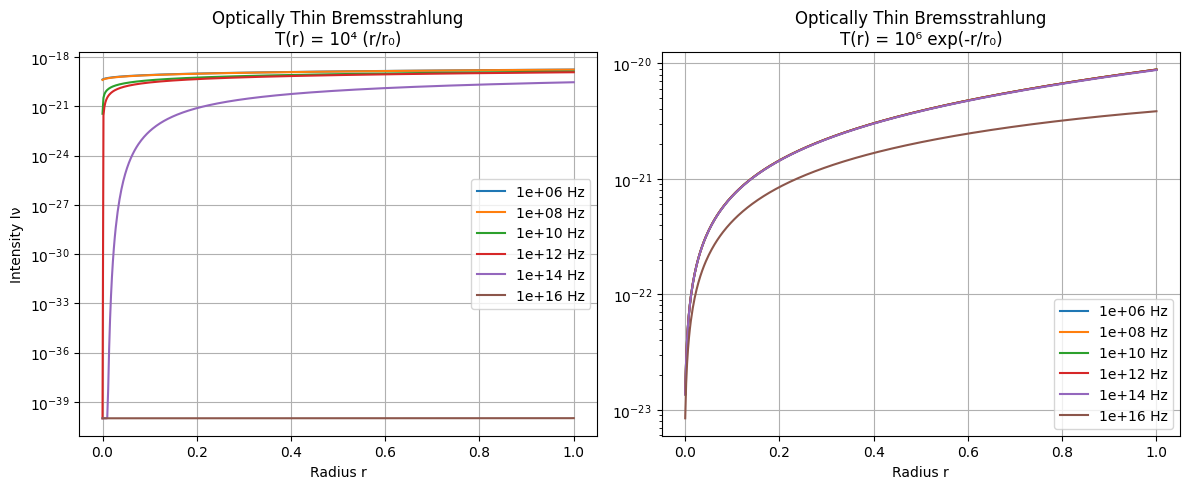

In [7]:
import numpy as np
import matplotlib.pyplot as plt
#in log scale
# ---------------- CONSTANTS ----------------
h = 6.626e-34       # Planck constant (J s)
kB = 1.38e-23       # Boltzmann constant (J/K)

# ---------------- PARAMETERS ----------------
r0 = 1.0
r = np.linspace(1e-5, r0, 500)   # avoid r = 0
dr = r[1] - r[0]

# Plasma parameters
n0 = 1e10      # electron density (m^-3)
ni = 1e10      # ion density (m^-3)
Z = 1
gff = 1        # Gaunt factor (kept symbolic)

# Frequency range (log spaced)
frequencies = np.logspace(6, 16, 6)

# ---------------- TEMPERATURE PROFILES ----------------
T1 = 1e4 * (r / r0) + 1e-10        # linear profile (avoid T=0)
T2 = 1e6 * np.exp(-r / r0)         # exponential profile

# ---------------- EMISSIVITY FUNCTION ----------------
def emissivity(nu, T):
    return 6.8e-38 * n0 * ni * Z**2 * gff * T**(-0.5) * np.exp(-h*nu/(kB*T))

# ---------------- FUNCTION TO COMPUTE INTENSITY ----------------
def compute_intensity(T):
    intensities = []
    
    for nu in frequencies:
        j = emissivity(nu, T)
        I = np.cumsum(j) * dr
        I += 1e-40   # avoid log(0)
        intensities.append(I)
    
    return intensities

# ---------------- COMPUTE ----------------
I_case1 = compute_intensity(T1)
I_case2 = compute_intensity(T2)

# ---------------- PLOTTING ----------------
plt.figure(figsize=(12,5))

# ---- Case (i): T ∝ r ----
plt.subplot(1,2,1)
for i, nu in enumerate(frequencies):
    plt.plot(r, I_case1[i], label=f"{nu:.0e} Hz")
plt.yscale('log')
plt.title("Optically Thin Bremsstrahlung\nT(r) = 10⁴ (r/r₀)")
plt.xlabel("Radius r")
plt.ylabel("Intensity Iν")
plt.legend()
plt.grid()

# ---- Case (ii): exponential ----
plt.subplot(1,2,2)
for i, nu in enumerate(frequencies):
    plt.plot(r, I_case2[i], label=f"{nu:.0e} Hz")
plt.yscale('log')
plt.title("Optically Thin Bremsstrahlung\nT(r) = 10⁶ exp(-r/r₀)")
plt.xlabel("Radius r")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()